<a href="https://colab.research.google.com/github/sitong0509/Beyond-Administrative-Boundaries-Measuring-Ethnic-Disparities-in-Violent-Crime-Exposure-in-London/blob/main/1_roadnetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1



In [ ]:
! pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 5.0 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import pandas as pd
from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import MultiPolygon
from IPython.display import IFrame
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely import wkt
from shapely.geometry import MultiPoint
from shapely.geometry import mapping
from shapely import geometry, ops
from shapely.geometry import MultiLineString
from shapely.ops import linemerge
from itertools import combinations
from shapely.wkt import loads
ox.settings.use_cache = True
ox.settings.log_console = True
import geopy.distance
import math
import numpy as np
from tqdm import tqdm
from scipy.spatial.distance import cdist
from geopy.distance import great_circle
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 2

In [ ]:
lsoa_geometry = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_LSOA2021/Camden_LSOA2021.shp')
lsoa_geometry = lsoa_geometry.to_crs('EPSG:4326')
lsoa_geometry

,LSOA21CD,LSOA21NM,GlobalID,geometry
0,E01000842,Camden 011A,9672d876-25b3-4797-8c35-8931e8610110,"POLYGON ((-0.16526 51.54729, -0.1646 51.54709,..."
1,E01000843,Camden 014A,ff8e83dc-84bd-47f4-b222-d75ffc735ad0,"POLYGON ((-0.16176 51.54869, -0.16043 51.54777..."
2,E01000844,Camden 011B,4a32d169-069b-4e6f-af55-b9d8746070b2,"POLYGON ((-0.17201 51.54657, -0.17061 51.54622..."
3,E01000845,Camden 014B,50465c31-d6b2-444f-89ef-9a1b2748d92e,"POLYGON ((-0.16027 51.5461, -0.15948 51.54566,..."
4,E01000846,Camden 014C,7ba87a06-21cd-44a5-bc84-5c0afc9cdf00,"POLYGON ((-0.16497 51.54481, -0.16478 51.54432..."
...,...,...,...,...
125,E01035708,Camden 022F,a3ddc6f2-bb81-4da6-a911-8893536aef4b,"POLYGON ((-0.13106 51.54212, -0.13071 51.54113..."
126,E01035709,Camden 022G,03cb43e8-2be6-424d-a41d-8bb298e17653,"POLYGON ((-0.12852 51.53679, -0.12636 51.53469..."
127,E01035710,Camden 023F,8619bf66-b5e3-4d93-8f5f-022280e9399a,"POLYGON ((-0.14093 51.53215, -0.14011 51.53178..."
128,E01035711,Camden 026E,bc7155f1-ed39-4249-88cf-59b039c519a5,"POLYGON ((-0.12873 51.52543, -0.12791 51.5247,..."


In [ ]:
merged_geometry_lsoa = lsoa_geometry.unary_union

exterior = Polygon(merged_geometry_lsoa.exterior)

merged_gdf = gpd.GeoDataFrame(geometry=[exterior], crs=lsoa_geometry.crs)

/tmp/ipykernel_382/1177363452.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geometry_lsoa = lsoa_geometry.unary_union


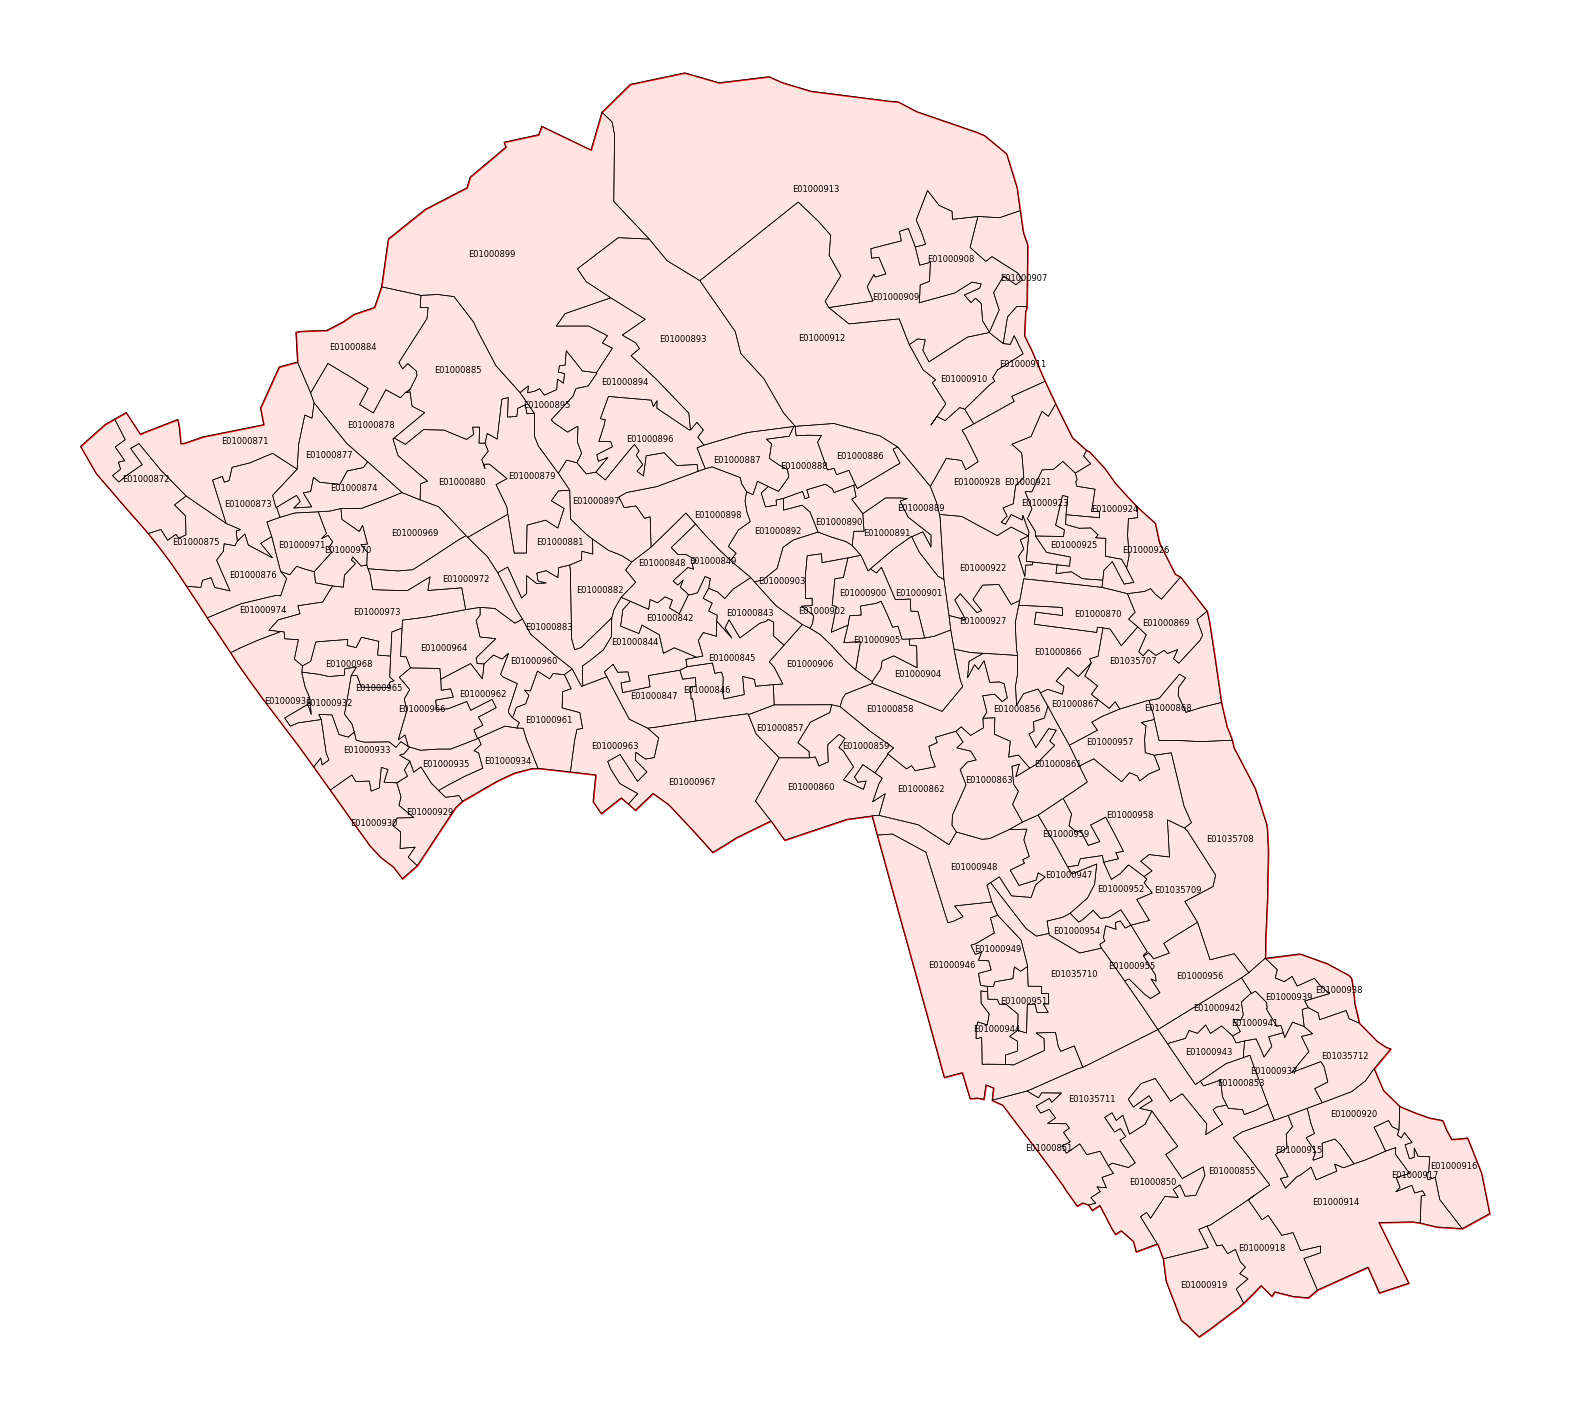

In [ ]:
fig, ax = plt.subplots(1, figsize=(20, 20))

polygon = gpd.GeoSeries([merged_gdf.iloc[0, 0]], crs='EPSG:4326')
polygon.plot(ax=ax, facecolor='mistyrose', edgecolor='red', linewidth=1, zorder=1)

lsoa_geometry.boundary.plot(ax=ax, color='black', linewidth=0.5, zorder=2)

# 标注 LSOA21CD
for _, r in lsoa_geometry.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(
        r['LSOA21CD'], xy=(p.x, p.y),
        ha='center', va='center', fontsize=6, zorder=3,
    )

ax.set_axis_off()
plt.show()

In [ ]:
buffer_dist = 1200  # （m）

# epsg=27700
gdf_proj = merged_gdf.copy().to_crs(epsg=27700)

gdf_proj['buffered_geom'] = gdf_proj.geometry.buffer(buffer_dist)

# epsg=4326
buffered_gdf = gdf_proj.set_geometry('buffered_geom').to_crs(epsg=4326)

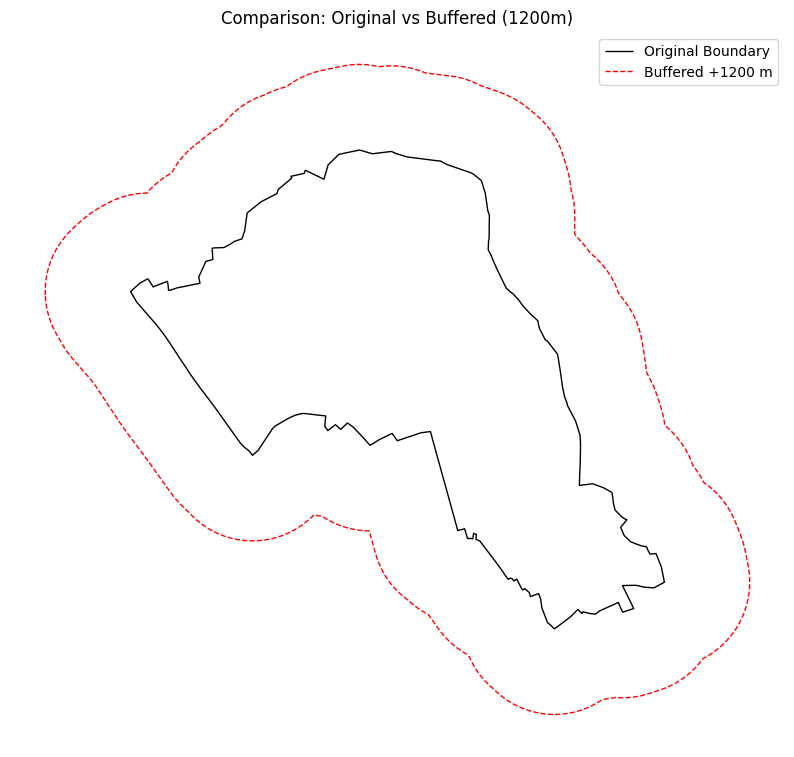

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_gdf.boundary.plot(ax=ax, color='black', linewidth=1, label='Original Boundary')

buffered_gdf.boundary.plot(
    ax=ax, color='red', linewidth=1, linestyle='--',
    label=f'Buffered +{buffer_dist:g} m'
)

plt.legend()
plt.title(f'Comparison: Original vs Buffered ({buffer_dist:g}m)')
plt.axis('off')
plt.show()

In [ ]:
buffered_gdf = buffered_gdf.to_crs(epsg=4326)

polygon = buffered_gdf.unary_union

G = ox.graph_from_polygon(polygon, network_type='walk', retain_all=True)

G = ox.project_graph(G, to_crs='EPSG:27700')

nodes, edges = ox.graph_to_gdfs(G)

/tmp/ipykernel_8699/2824937692.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = buffered_gdf.unary_union


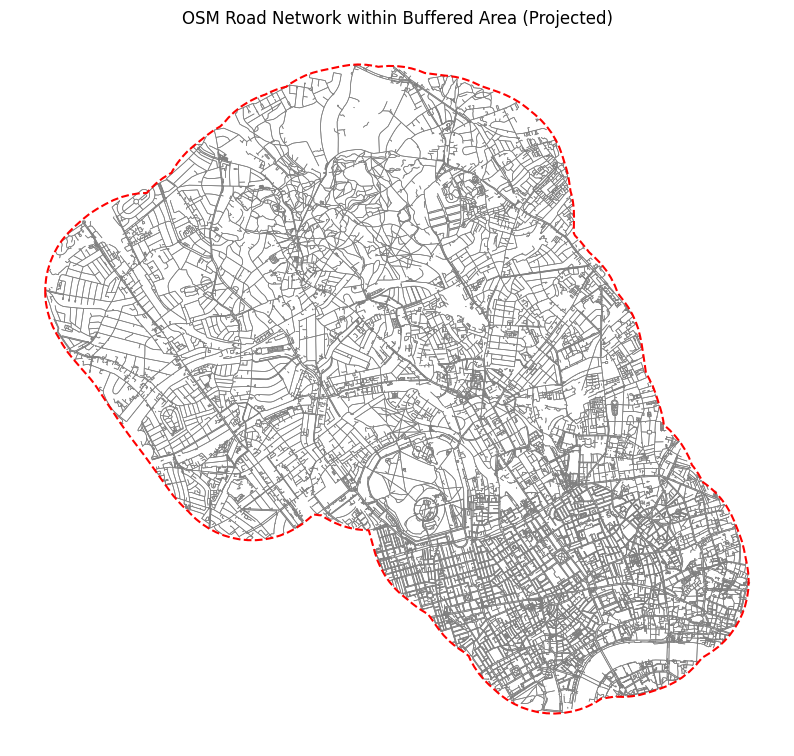

In [ ]:
edges_proj = edges.to_crs(buffered_gdf.crs)

fig, ax = plt.subplots(figsize=(10, 10))
edges_proj.plot(ax=ax, linewidth=0.5, color='gray')
buffered_gdf.boundary.plot(ax=ax, color='red', linestyle='--')
plt.title('OSM Road Network within Buffered Area (Projected)')
plt.axis('off')
plt.show()

In [ ]:
from pathlib import Path

base_dir = Path('/content/drive/MyDrive/RQ2/github/Camden_roadnetwork')

out_dir = base_dir / f'Camden_road_{buffer_dist:g}m'

out_dir.mkdir(parents=True, exist_ok=True)

edges_path = out_dir / 'edges_buffered_WALK.geojson'
nodes_path = out_dir / 'nodes_buffered_WALK.geojson'

edges.to_file(edges_path, driver='GeoJSON')
nodes.to_file(nodes_path, driver='GeoJSON')